In [ ]:
# =============================================================================
# NOTEBOOK 4: VISUALIZATION AND ANALYSIS
# =============================================================================
# Purpose: Create comprehensive visualizations of discovered traffic patterns,
# temporal plots, cluster analyses, and anomaly visualizations to support
# interpretation and presentation of findings.
# =============================================================================


In [1]:
# ---- Cell 1: Import Libraries and Load Results ----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import ListedColormap
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load all results from previous notebooks
temporal_df = pd.read_hdf('../data/temporal_features_clustered.h5')
df_clean = pd.read_hdf('../data/metr_la_cleaned.h5')
X_pca_2d = np.load('../data/X_pca_2d.npy')
X_pca_3d = np.load('../data/X_pca_3d.npy')
final_labels = np.load('../data/final_labels.npy')
dbscan_labels = np.load('../data/dbscan_labels.npy')
hdbscan_labels = np.load('../data/hdbscan_labels.npy')

with open('../data/feature_names.json', 'r') as f:
    feature_names = json.load(f)

# FIX: 'time_period' was dropped before saving in Notebook 2/3 to keep HDF5
# compatible (it is a string column). Reconstruct it here from 'hour'.
def classify_time_period(hour):
    if 6 <= hour < 10:
        return 'morning_rush'
    elif 10 <= hour < 15:
        return 'midday'
    elif 15 <= hour < 19:
        return 'evening_rush'
    elif 19 <= hour < 22:
        return 'evening'
    else:
        return 'night'

temporal_df['time_period'] = temporal_df['hour'].apply(classify_time_period)

print(f"Data loaded successfully")
print(f"Time range: {temporal_df.index[0]} to {temporal_df.index[-1]}")
print(f"Number of clusters: {len(set(final_labels)) - (1 if -1 in final_labels else 0)}")

# Define color scheme for clusters
n_unique = len(set(final_labels))
cluster_colors = plt.cm.Set2(np.linspace(0, 1, n_unique))


Data loaded successfully
Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Number of clusters: 4


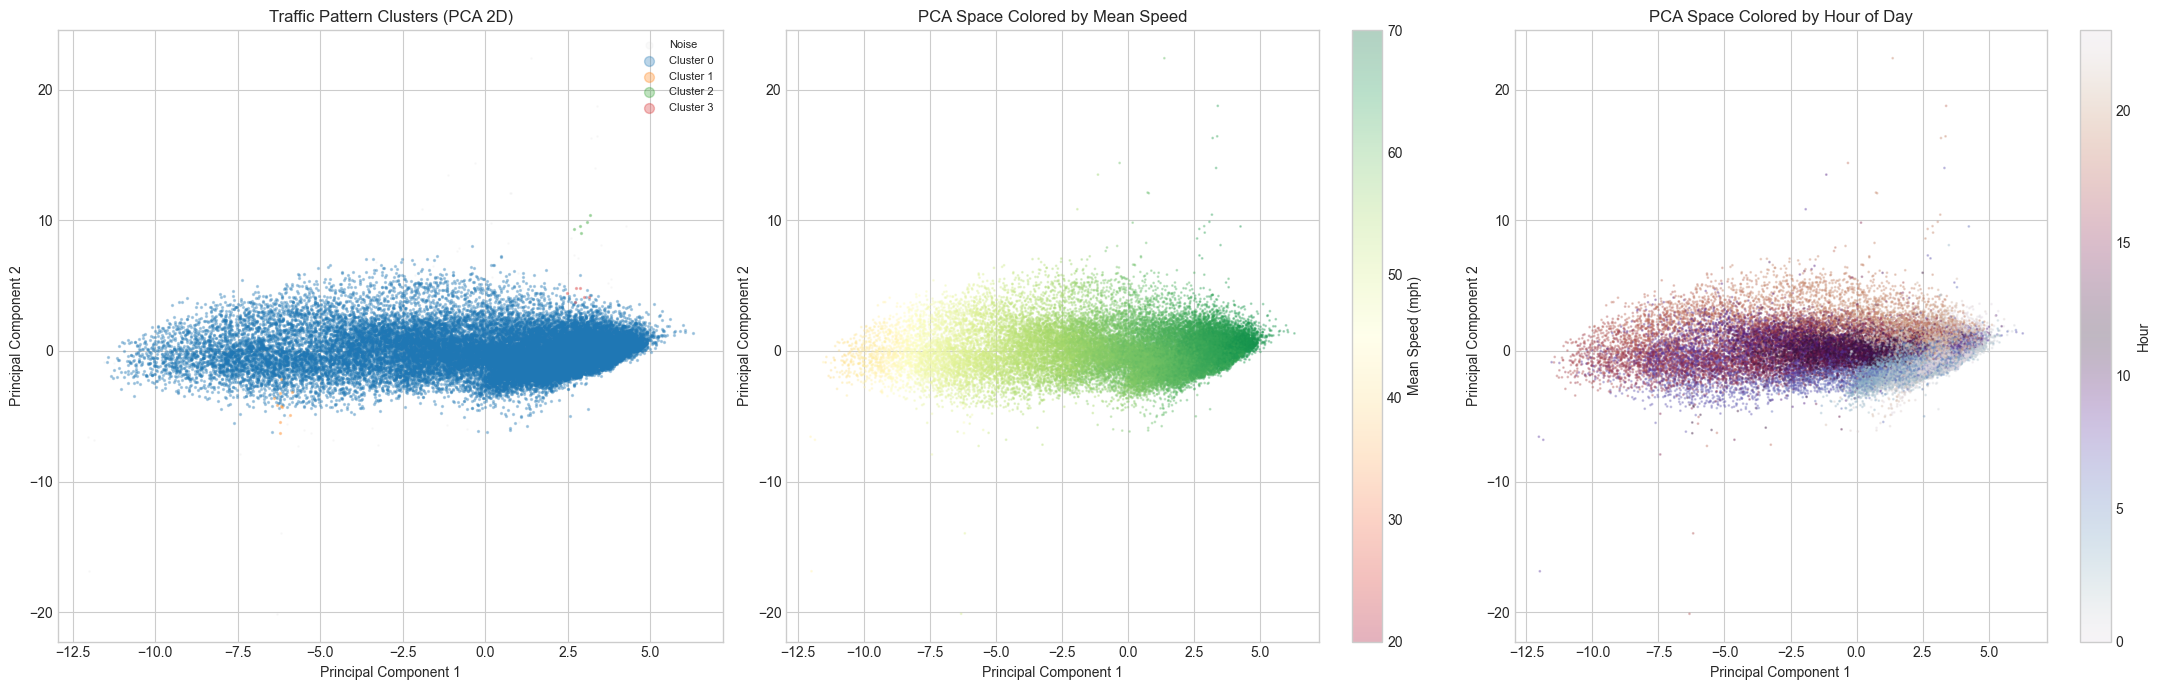

In [2]:
# ---- Cell 2: Enhanced 2D PCA Cluster Visualization ----
# Create a detailed 2D scatter plot showing cluster structure

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: Colored by cluster
unique_labels = sorted(set(final_labels))
for label in unique_labels:
    mask = final_labels == label
    name = "Noise" if label == -1 else f"Cluster {label}"
    color = 'lightgray' if label == -1 else None
    alpha = 0.1 if label == -1 else 0.3
    size = 1 if label == -1 else 2
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    s=size, alpha=alpha, label=name, c=color)

axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].set_title('Traffic Pattern Clusters (PCA 2D)')
axes[0].legend(markerscale=5, loc='best', fontsize=8)

# Plot 2: Colored by mean speed
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=temporal_df['mean_speed'], cmap='RdYlGn',
                           s=1, alpha=0.3, vmin=20, vmax=70)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA Space Colored by Mean Speed')
plt.colorbar(scatter2, ax=axes[1], label='Mean Speed (mph)')

# Plot 3: Colored by hour of day
scatter3 = axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=temporal_df['hour'], cmap='twilight',
                           s=1, alpha=0.3)
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')
axes[2].set_title('PCA Space Colored by Hour of Day')
plt.colorbar(scatter3, ax=axes[2], label='Hour')

plt.tight_layout()
plt.savefig('../data/viz_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

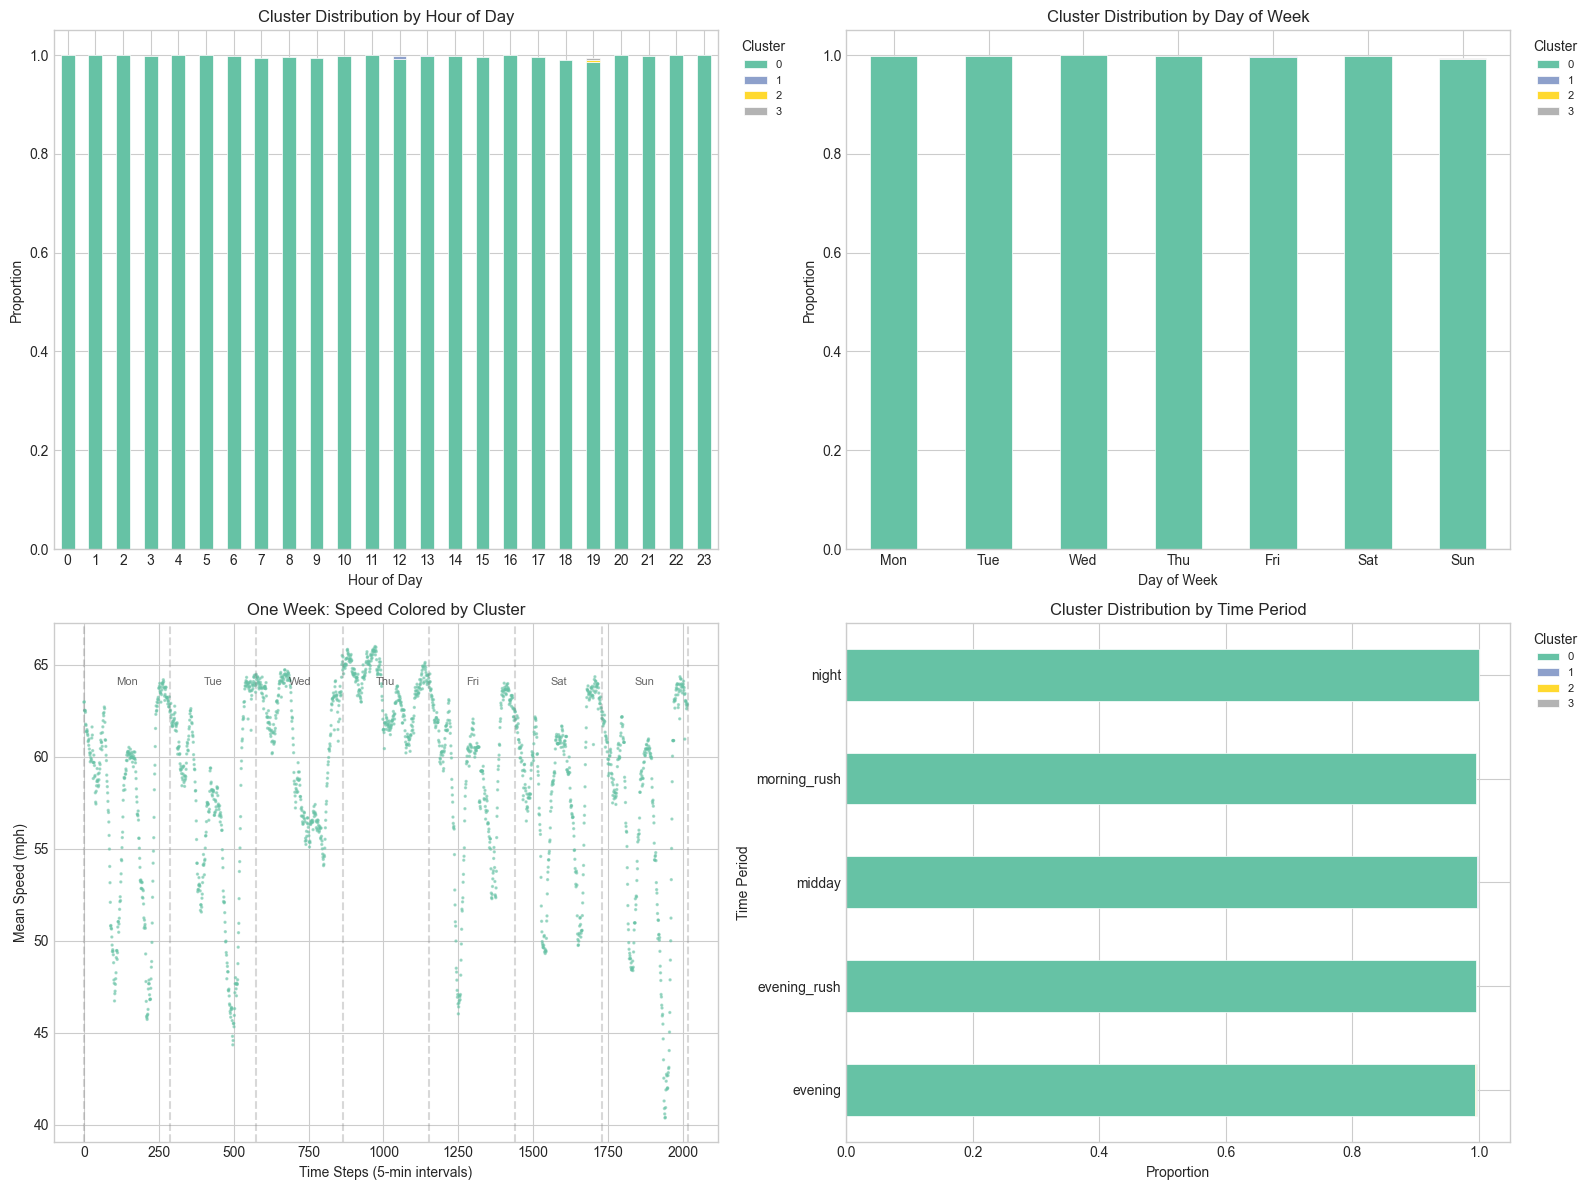

In [3]:
# ---- Cell 3: Temporal Distribution of Clusters ----
# Show when each cluster occurs throughout the day and week

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cluster distribution by hour of day
cluster_hour_dist = pd.crosstab(temporal_df['hour'], final_labels, normalize='index')
plot_cols = [c for c in cluster_hour_dist.columns if c != -1]
cluster_hour_dist[plot_cols].plot(kind='bar', stacked=True, ax=axes[0, 0],
                                  colormap='Set2', edgecolor='white', linewidth=0.5)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].set_title('Cluster Distribution by Hour of Day')
axes[0, 0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), fontsize=8)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# Plot 2: Cluster distribution by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
cluster_dow_dist = pd.crosstab(temporal_df['day_of_week'], final_labels, normalize='index')
cluster_dow_dist[plot_cols].plot(kind='bar', stacked=True, ax=axes[0, 1],
                                 colormap='Set2', edgecolor='white', linewidth=0.5)
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].set_title('Cluster Distribution by Day of Week')
axes[0, 1].set_xticklabels(day_names, rotation=0)
axes[0, 1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), fontsize=8)

# Plot 3: Hourly cluster timeline for one typical week
one_week = temporal_df.iloc[:2016]
one_week_labels = final_labels[:2016]

axes[1, 0].scatter(range(len(one_week)), one_week['mean_speed'],
                    c=one_week_labels, cmap='Set2', s=2, alpha=0.5)
axes[1, 0].set_xlabel('Time Steps (5-min intervals)')
axes[1, 0].set_ylabel('Mean Speed (mph)')
axes[1, 0].set_title('One Week: Speed Colored by Cluster')

for day in range(8):
    axes[1, 0].axvline(x=day * 288, color='gray', linestyle='--', alpha=0.3)
    if day < 7:
        axes[1, 0].text(day * 288 + 144, axes[1, 0].get_ylim()[1] * 0.95,
                        day_names[day], ha='center', fontsize=8, alpha=0.7)

# Plot 4: Cluster distribution by time period
cluster_period = pd.crosstab(temporal_df['time_period'], final_labels, normalize='index')
period_plot_cols = [c for c in cluster_period.columns if c != -1]
cluster_period[period_plot_cols].plot(kind='barh', stacked=True, ax=axes[1, 1],
                               colormap='Set2', edgecolor='white', linewidth=0.5)
axes[1, 1].set_xlabel('Proportion')
axes[1, 1].set_ylabel('Time Period')
axes[1, 1].set_title('Cluster Distribution by Time Period')
axes[1, 1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.savefig('../data/viz_temporal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

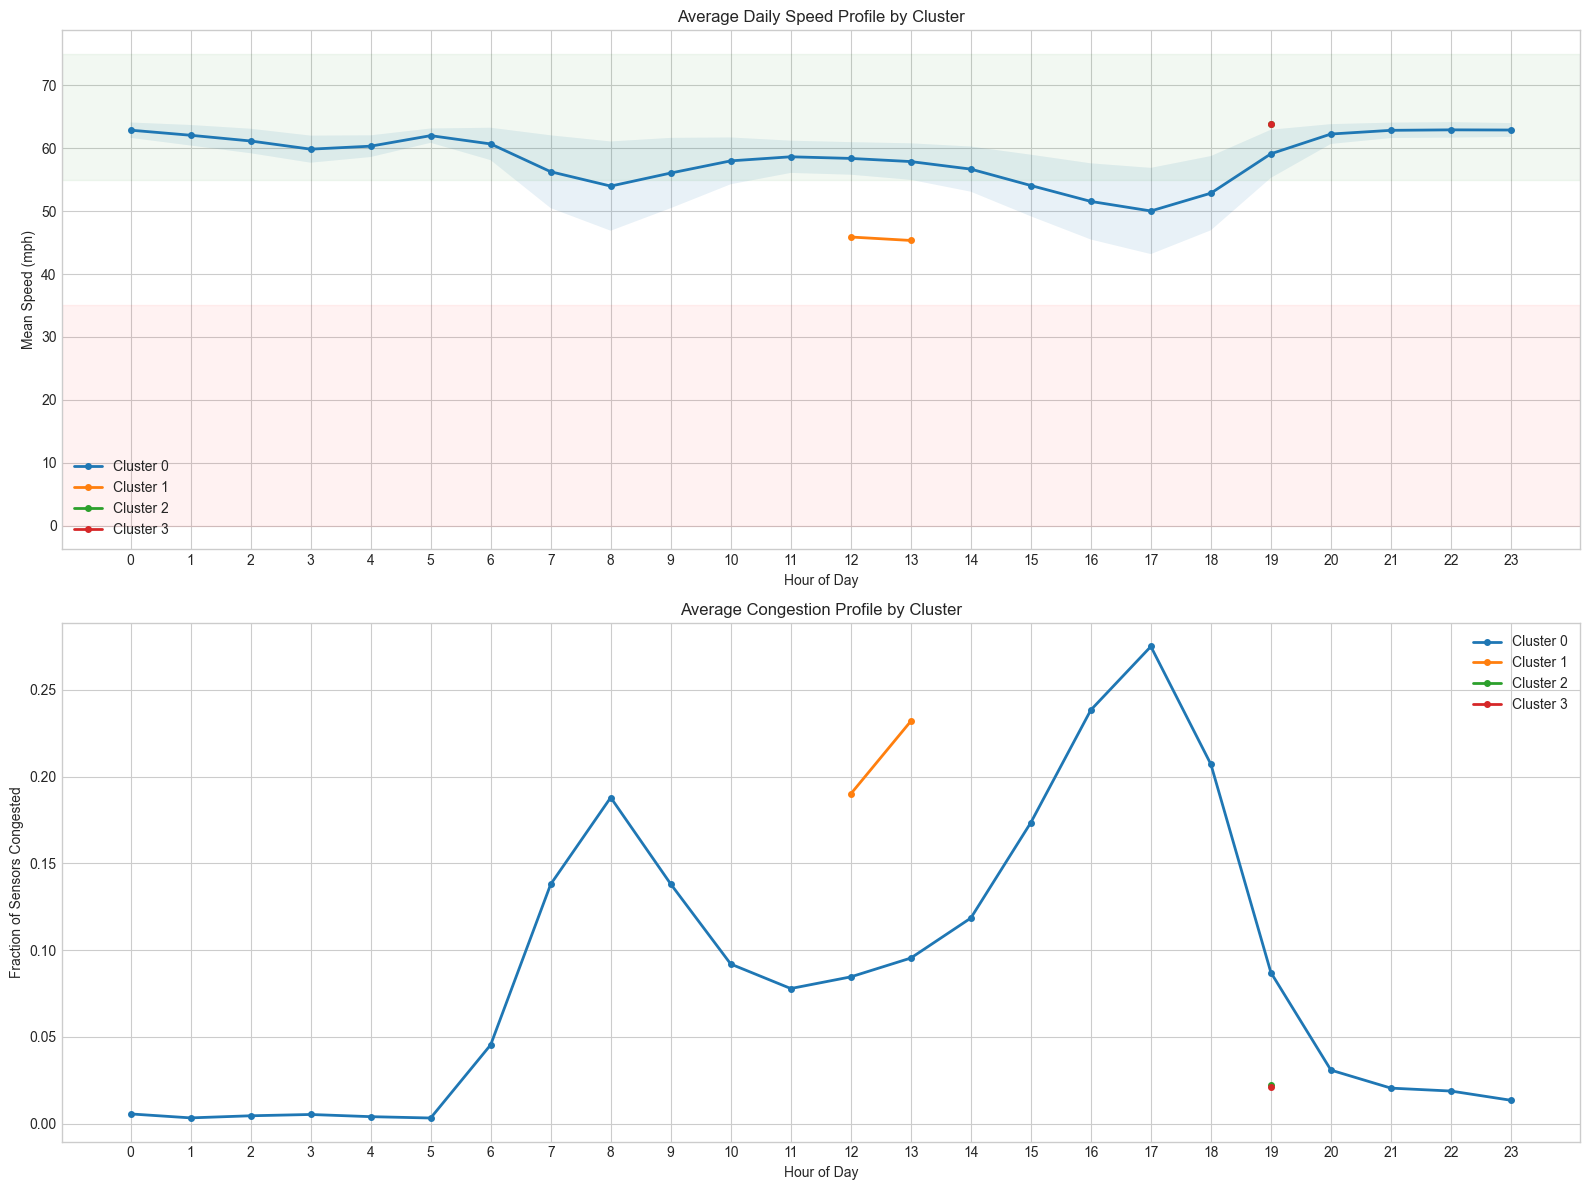

In [4]:

# ---- Cell 4: Average Daily Traffic Profile by Cluster ----

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for cluster_id in sorted(set(final_labels)):
    if cluster_id == -1:
        continue
    mask = final_labels == cluster_id
    cluster_data = temporal_df[mask]

    hourly_mean = cluster_data.groupby('hour')['mean_speed'].mean()
    hourly_std = cluster_data.groupby('hour')['mean_speed'].std()

    axes[0].plot(hourly_mean.index, hourly_mean.values,
                 'o-', linewidth=2, markersize=4, label=f'Cluster {cluster_id}')
    axes[0].fill_between(hourly_mean.index,
                         hourly_mean - hourly_std,
                         hourly_mean + hourly_std, alpha=0.1)

axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Speed (mph)')
axes[0].set_title('Average Daily Speed Profile by Cluster')
axes[0].legend()
axes[0].set_xticks(range(24))
axes[0].axhspan(0, 35, alpha=0.05, color='red', label='Congestion zone')
axes[0].axhspan(55, 75, alpha=0.05, color='green')

for cluster_id in sorted(set(final_labels)):
    if cluster_id == -1:
        continue
    mask = final_labels == cluster_id
    cluster_data = temporal_df[mask]

    hourly_congestion = cluster_data.groupby('hour')['frac_congested'].mean()
    axes[1].plot(hourly_congestion.index, hourly_congestion.values,
                 'o-', linewidth=2, markersize=4, label=f'Cluster {cluster_id}')

axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraction of Sensors Congested')
axes[1].set_title('Average Congestion Profile by Cluster')
axes[1].legend()
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig('../data/viz_daily_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


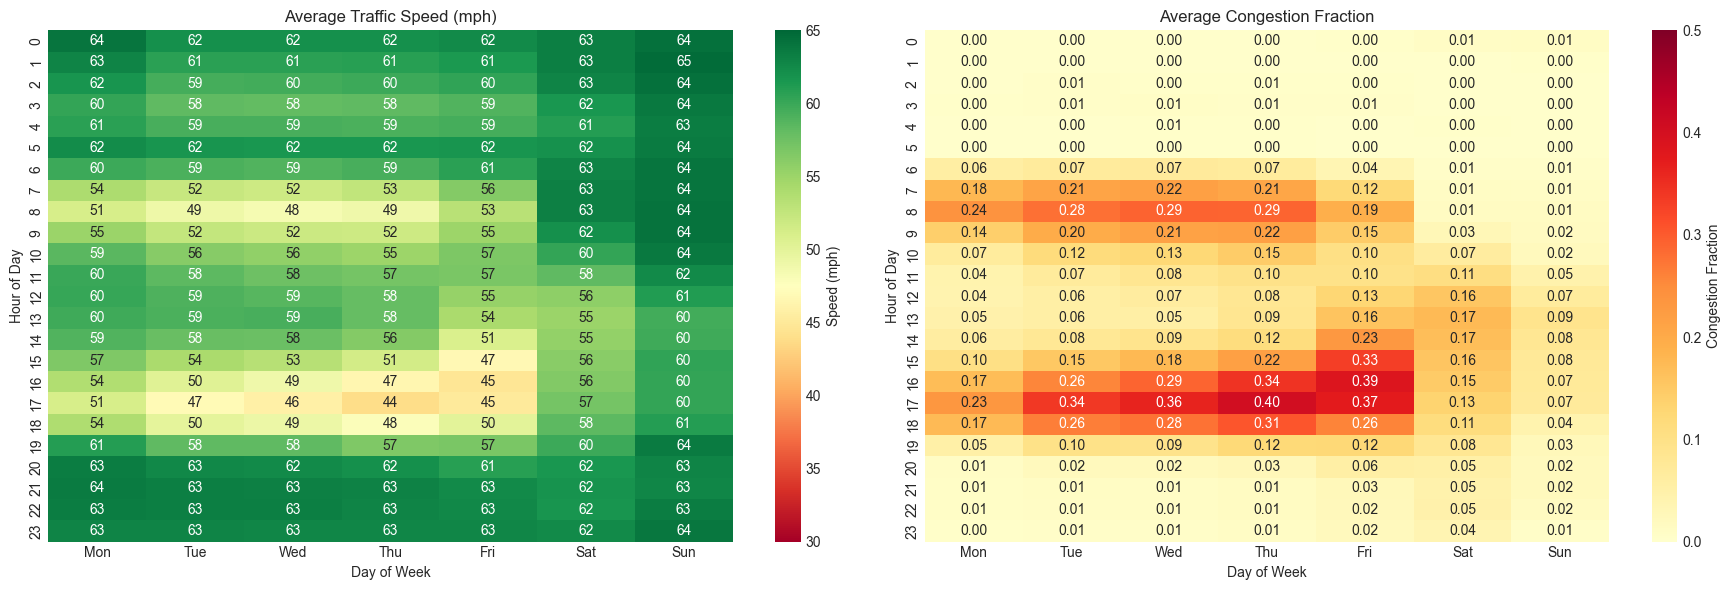

In [5]:
# ---- Cell 5: Speed Heatmap by Hour and Day ----

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pivot_speed = temporal_df.pivot_table(values='mean_speed',
                                       index='hour',
                                       columns='day_of_week',
                                       aggfunc='mean')
pivot_speed.columns = day_names
sns.heatmap(pivot_speed, cmap='RdYlGn', annot=True, fmt='.0f',
            ax=axes[0], cbar_kws={'label': 'Speed (mph)'},
            vmin=30, vmax=65)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Hour of Day')
axes[0].set_title('Average Traffic Speed (mph)')

pivot_congestion = temporal_df.pivot_table(values='frac_congested',
                                            index='hour',
                                            columns='day_of_week',
                                            aggfunc='mean')
pivot_congestion.columns = day_names
sns.heatmap(pivot_congestion, cmap='YlOrRd', annot=True, fmt='.2f',
            ax=axes[1], cbar_kws={'label': 'Congestion Fraction'},
            vmin=0, vmax=0.5)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')
axes[1].set_title('Average Congestion Fraction')

plt.tight_layout()
plt.savefig('../data/viz_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

ANOMALY ANALYSIS
Total anomalous time steps: 78
Percentage of total: 0.23%


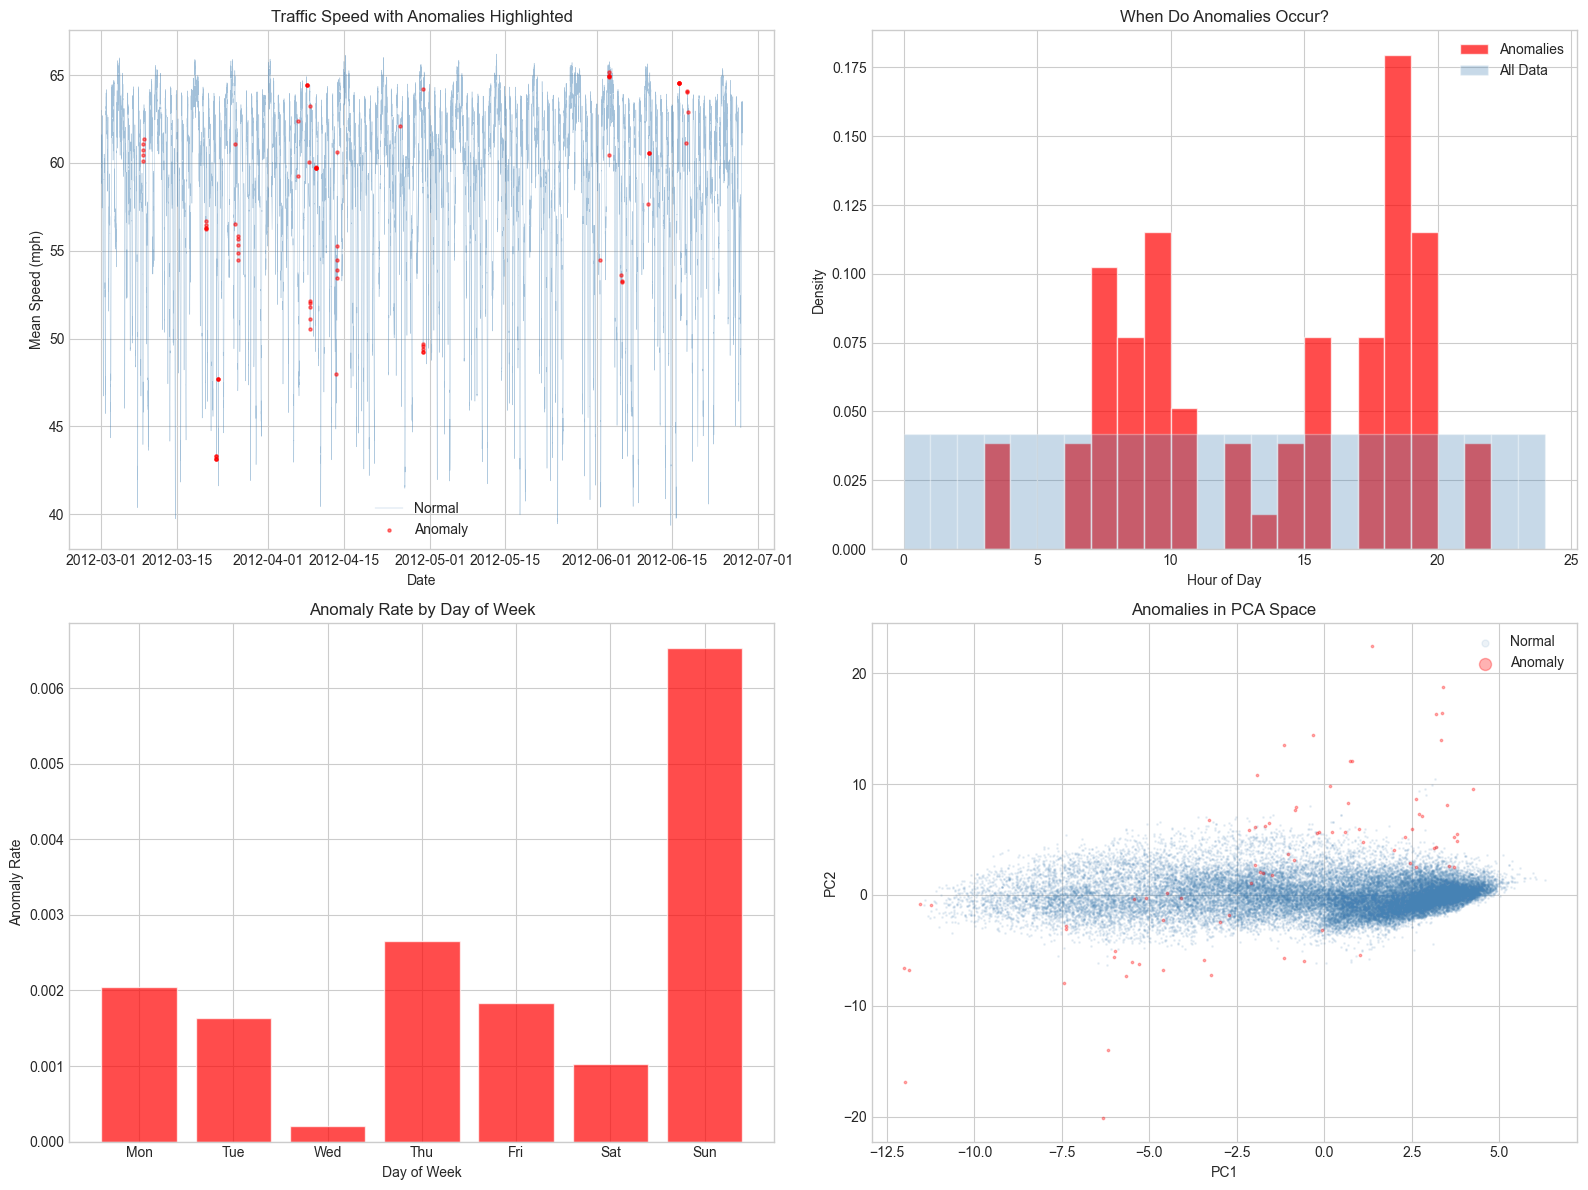


Anomaly Characteristics:
  Mean speed: 57.0 mph (vs normal: 58.5 mph)
  Speed volatility: 3.55 (vs normal: 0.52)
  Congestion fraction: 0.089 (vs normal: 0.086)


In [7]:
# ---- Cell 6: Anomaly Detection Visualization ----

print("=" * 60)
print("ANOMALY ANALYSIS")
print("=" * 60)

anomaly_mask = final_labels == -1
n_anomalies = anomaly_mask.sum()
print(f"Total anomalous time steps: {n_anomalies}")
print(f"Percentage of total: {n_anomalies/len(final_labels)*100:.2f}%")

anomaly_df = temporal_df[anomaly_mask]

if n_anomalies > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    axes[0, 0].plot(temporal_df.index, temporal_df['mean_speed'],
                    color='steelblue', linewidth=0.3, alpha=0.5, label='Normal')
    axes[0, 0].scatter(anomaly_df.index, anomaly_df['mean_speed'],
                       color='red', s=5, alpha=0.5, label='Anomaly', zorder=5)
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Mean Speed (mph)')
    axes[0, 0].set_title('Traffic Speed with Anomalies Highlighted')
    axes[0, 0].legend()

    axes[0, 1].hist(anomaly_df['hour'], bins=24, range=(0, 24),
                    color='red', alpha=0.7, edgecolor='white', density=True,
                    label='Anomalies')
    axes[0, 1].hist(temporal_df['hour'], bins=24, range=(0, 24),
                    color='steelblue', alpha=0.3, edgecolor='white', density=True,
                    label='All Data')
    axes[0, 1].set_xlabel('Hour of Day')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].set_title('When Do Anomalies Occur?')
    axes[0, 1].legend()

    anomaly_dow = anomaly_df['day_of_week'].value_counts().sort_index()
    all_dow = temporal_df['day_of_week'].value_counts().sort_index()
    anomaly_rate = anomaly_dow / all_dow

    axes[1, 0].bar(range(7), anomaly_rate.values, color='red', alpha=0.7,
                   edgecolor='white')
    axes[1, 0].set_xticks(range(7))
    axes[1, 0].set_xticklabels(day_names)
    axes[1, 0].set_xlabel('Day of Week')
    axes[1, 0].set_ylabel('Anomaly Rate')
    axes[1, 0].set_title('Anomaly Rate by Day of Week')

    normal_mask = ~anomaly_mask
    axes[1, 1].scatter(X_pca_2d[normal_mask, 0], X_pca_2d[normal_mask, 1],
                       c='steelblue', s=1, alpha=0.1, label='Normal')
    axes[1, 1].scatter(X_pca_2d[anomaly_mask, 0], X_pca_2d[anomaly_mask, 1],
                       c='red', s=3, alpha=0.3, label='Anomaly')
    axes[1, 1].set_xlabel('PC1')
    axes[1, 1].set_ylabel('PC2')
    axes[1, 1].set_title('Anomalies in PCA Space')
    axes[1, 1].legend(markerscale=5)

    plt.tight_layout()
    plt.savefig('../data/viz_anomalies.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nAnomaly Characteristics:")
    print(f"  Mean speed: {anomaly_df['mean_speed'].mean():.1f} mph "
          f"(vs normal: {temporal_df[~anomaly_mask]['mean_speed'].mean():.1f} mph)")
    print(f"  Speed volatility: {anomaly_df['speed_volatility_30min'].mean():.2f} "
          f"(vs normal: {temporal_df[~anomaly_mask]['speed_volatility_30min'].mean():.2f})")
    print(f"  Congestion fraction: {anomaly_df['frac_congested'].mean():.3f} "
          f"(vs normal: {temporal_df[~anomaly_mask]['frac_congested'].mean():.3f})")


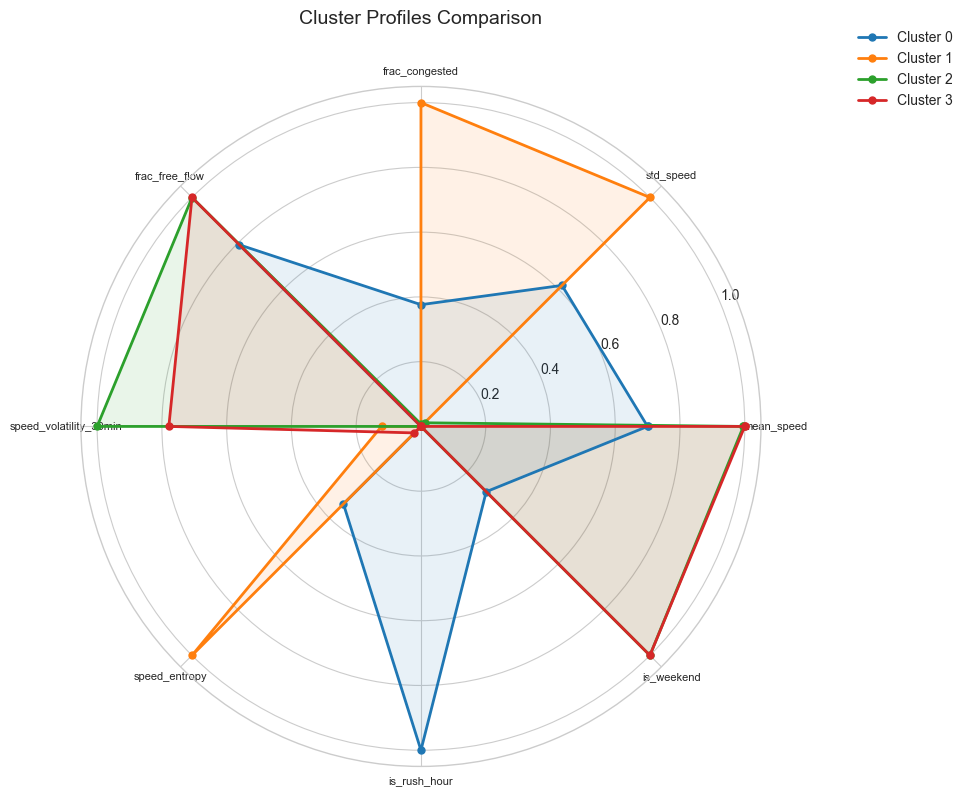

In [8]:
# ---- Cell 7: Cluster Characteristics Radar Chart ----

from matplotlib.patches import FancyBboxPatch

profile_features = ['mean_speed', 'std_speed', 'frac_congested',
                     'frac_free_flow', 'speed_volatility_30min',
                     'speed_entropy', 'is_rush_hour', 'is_weekend']

cluster_profiles = {}
for cluster_id in sorted(set(final_labels)):
    if cluster_id == -1:
        continue
    mask = final_labels == cluster_id
    profile = temporal_df[mask][profile_features].mean()
    cluster_profiles[f'Cluster {cluster_id}'] = profile

profiles_df = pd.DataFrame(cluster_profiles).T

profiles_normalized = (profiles_df - profiles_df.min()) / (profiles_df.max() - profiles_df.min())

n_vars = len(profile_features)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cluster_name, values in profiles_normalized.iterrows():
    vals = values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, markersize=5, label=cluster_name)
    ax.fill(angles, vals, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_features, fontsize=8)
ax.set_title('Cluster Profiles Comparison', fontsize=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../data/viz_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


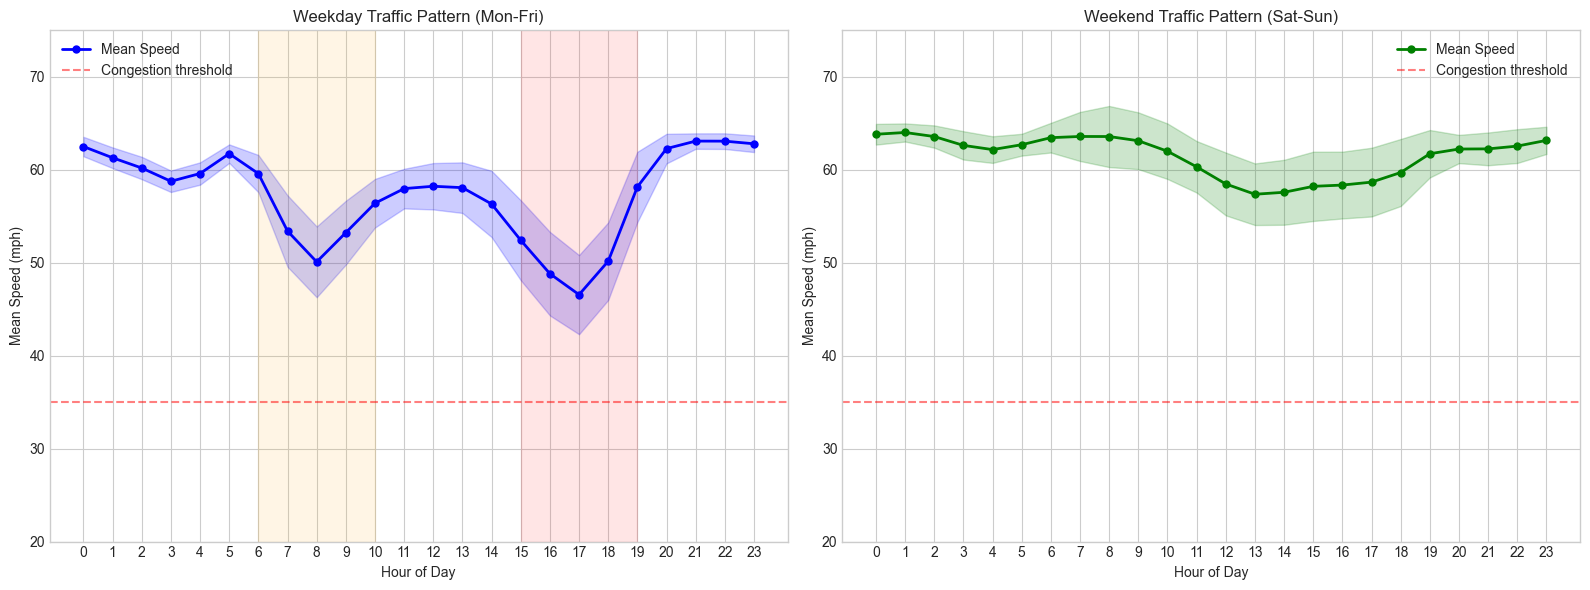

In [9]:
# ---- Cell 8: Weekday vs Weekend Pattern Comparison ----

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

weekday_data = temporal_df[temporal_df['is_weekend'] == 0]
weekday_hourly = weekday_data.groupby('hour')['mean_speed'].agg(['mean', 'std'])

axes[0].plot(weekday_hourly.index, weekday_hourly['mean'],
             'b-o', linewidth=2, markersize=5, label='Mean Speed')
axes[0].fill_between(weekday_hourly.index,
                     weekday_hourly['mean'] - weekday_hourly['std'],
                     weekday_hourly['mean'] + weekday_hourly['std'],
                     alpha=0.2, color='blue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Speed (mph)')
axes[0].set_title('Weekday Traffic Pattern (Mon-Fri)')
axes[0].set_xticks(range(24))
axes[0].set_ylim(20, 75)
axes[0].axhline(y=35, color='red', linestyle='--', alpha=0.5, label='Congestion threshold')
axes[0].legend()
axes[0].axvspan(6, 10, alpha=0.1, color='orange', label='Morning Rush')
axes[0].axvspan(15, 19, alpha=0.1, color='red', label='Evening Rush')

weekend_data = temporal_df[temporal_df['is_weekend'] == 1]
weekend_hourly = weekend_data.groupby('hour')['mean_speed'].agg(['mean', 'std'])

axes[1].plot(weekend_hourly.index, weekend_hourly['mean'],
             'g-o', linewidth=2, markersize=5, label='Mean Speed')
axes[1].fill_between(weekend_hourly.index,
                     weekend_hourly['mean'] - weekend_hourly['std'],
                     weekend_hourly['mean'] + weekend_hourly['std'],
                     alpha=0.2, color='green')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Speed (mph)')
axes[1].set_title('Weekend Traffic Pattern (Sat-Sun)')
axes[1].set_xticks(range(24))
axes[1].set_ylim(20, 75)
axes[1].axhline(y=35, color='red', linestyle='--', alpha=0.5, label='Congestion threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/viz_weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

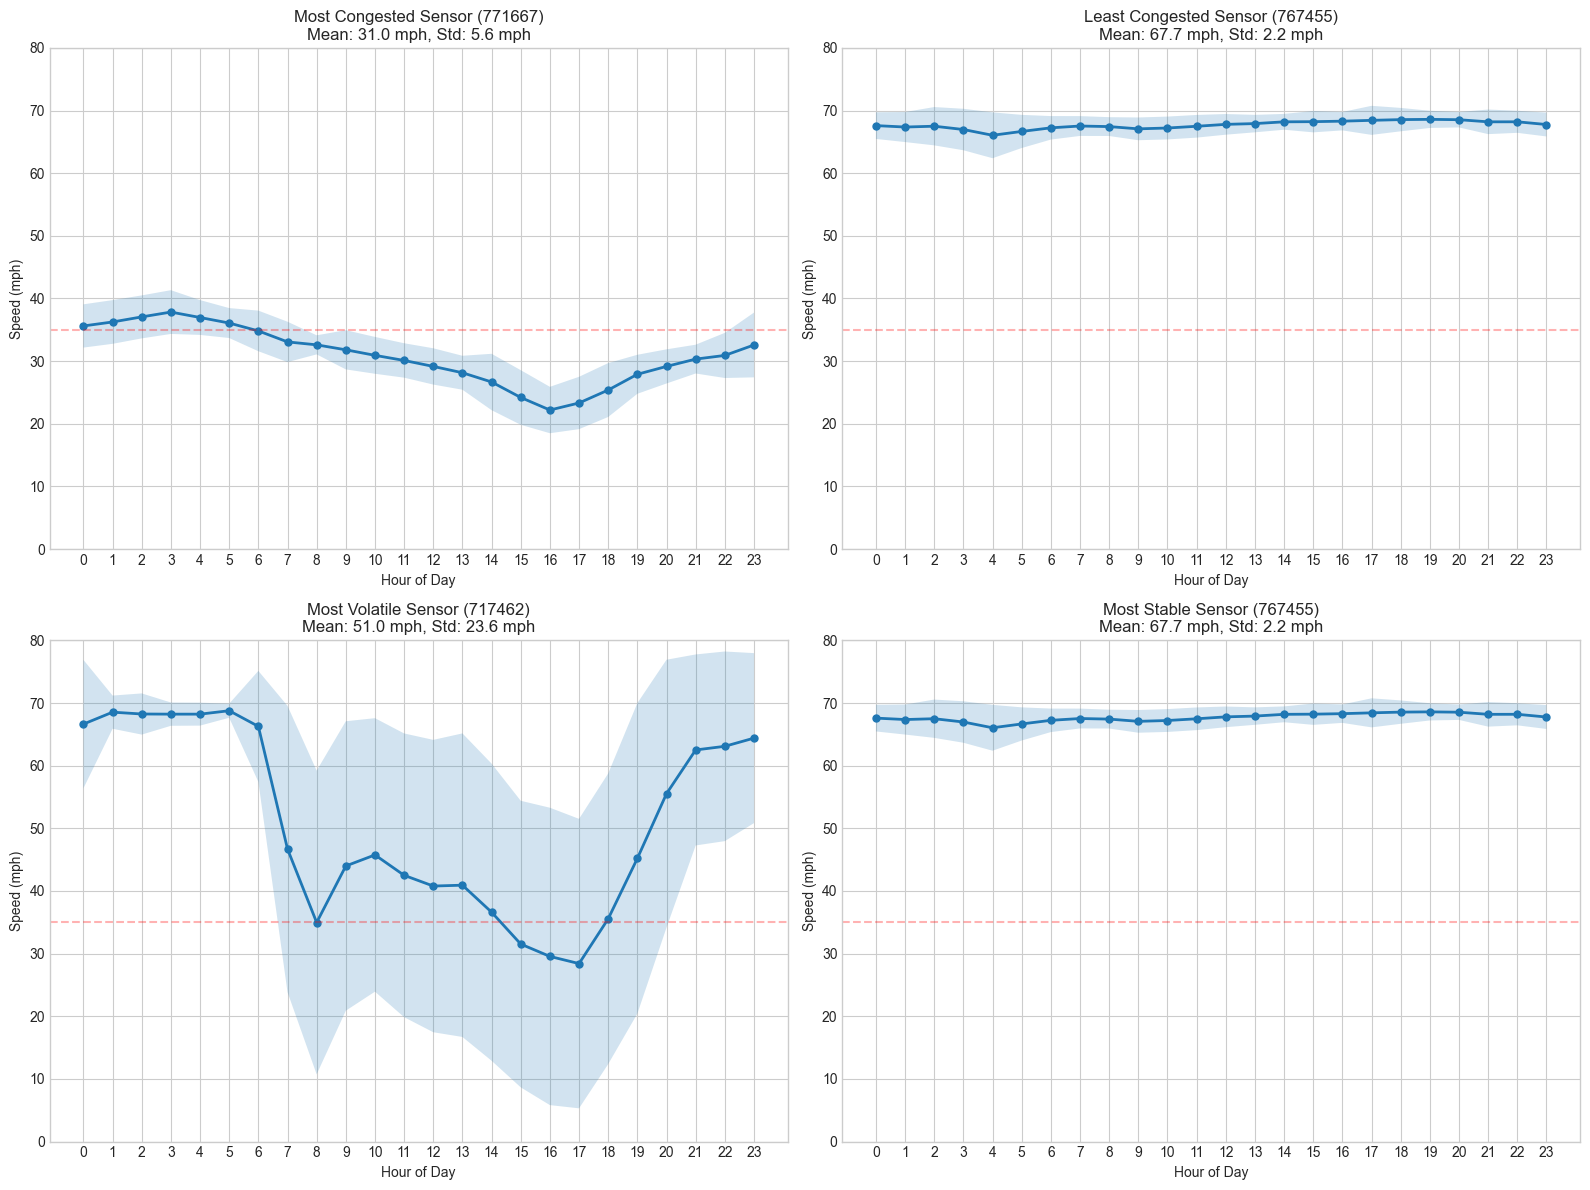

In [10]:


# ---- Cell 9: Individual Sensor Pattern Analysis ----

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sensor_stats = pd.DataFrame({
    'mean': df_clean.mean(),
    'std': df_clean.std(),
    'min': df_clean.min()
})

most_congested = sensor_stats['mean'].idxmin()
least_congested = sensor_stats['mean'].idxmax()
most_volatile = sensor_stats['std'].idxmax()
most_stable = sensor_stats['std'].idxmin()

sensors = {
    'Most Congested': most_congested,
    'Least Congested': least_congested,
    'Most Volatile': most_volatile,
    'Most Stable': most_stable
}

for idx, (label, sensor_id) in enumerate(sensors.items()):
    ax = axes[idx // 2, idx % 2]

    sensor_data = df_clean[sensor_id].copy()
    sensor_data_df = pd.DataFrame({'speed': sensor_data})
    sensor_data_df['hour'] = sensor_data_df.index.hour
    hourly_profile = sensor_data_df.groupby('hour')['speed'].agg(['mean', 'std'])

    ax.plot(hourly_profile.index, hourly_profile['mean'],
            'o-', linewidth=2, markersize=5)
    ax.fill_between(hourly_profile.index,
                    hourly_profile['mean'] - hourly_profile['std'],
                    hourly_profile['mean'] + hourly_profile['std'],
                    alpha=0.2)

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Speed (mph)')
    ax.set_title(f'{label} Sensor ({sensor_id})\n'
                 f'Mean: {sensor_stats.loc[sensor_id, "mean"]:.1f} mph, '
                 f'Std: {sensor_stats.loc[sensor_id, "std"]:.1f} mph')
    ax.set_xticks(range(24))
    ax.set_ylim(0, 80)
    ax.axhline(y=35, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/viz_sensor_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

CLUSTER TRANSITION ANALYSIS
Cluster Transition Matrix (row -> column probability):
col_0     -1      0      1      2      3
row_0                                   
-1     0.603  0.333  0.013  0.038  0.013
 0     0.001  0.999  0.000  0.000  0.000
 1     0.000  0.100  0.900  0.000  0.000
 2     0.200  0.000  0.000  0.400  0.400
 3     0.000  0.500  0.000  0.000  0.500


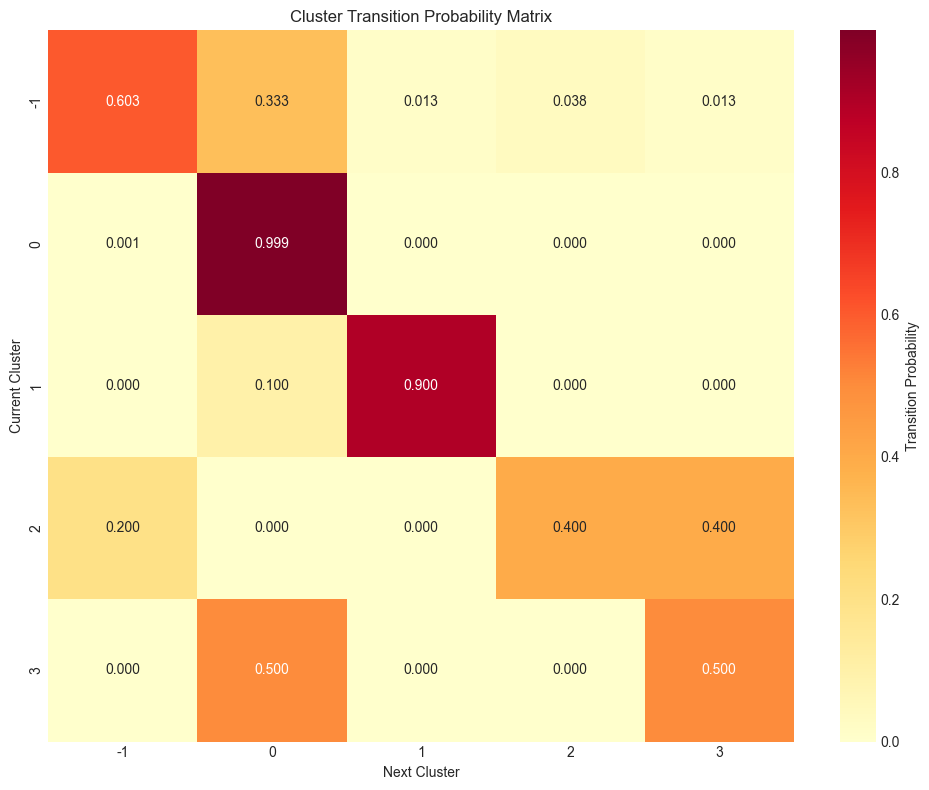

In [11]:


# ---- Cell 10: Cluster Transition Analysis ----

print("=" * 60)
print("CLUSTER TRANSITION ANALYSIS")
print("=" * 60)

labels_series = pd.Series(final_labels, index=temporal_df.index)
transitions = pd.crosstab(labels_series[:-1].values, labels_series[1:].values,
                          normalize='index')

print("Cluster Transition Matrix (row -> column probability):")
print(transitions.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(transitions, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'Transition Probability'})
ax.set_xlabel('Next Cluster')
ax.set_ylabel('Current Cluster')
ax.set_title('Cluster Transition Probability Matrix')
plt.tight_layout()
plt.savefig('../data/viz_transitions.png', dpi=150, bbox_inches='tight')
plt.show()

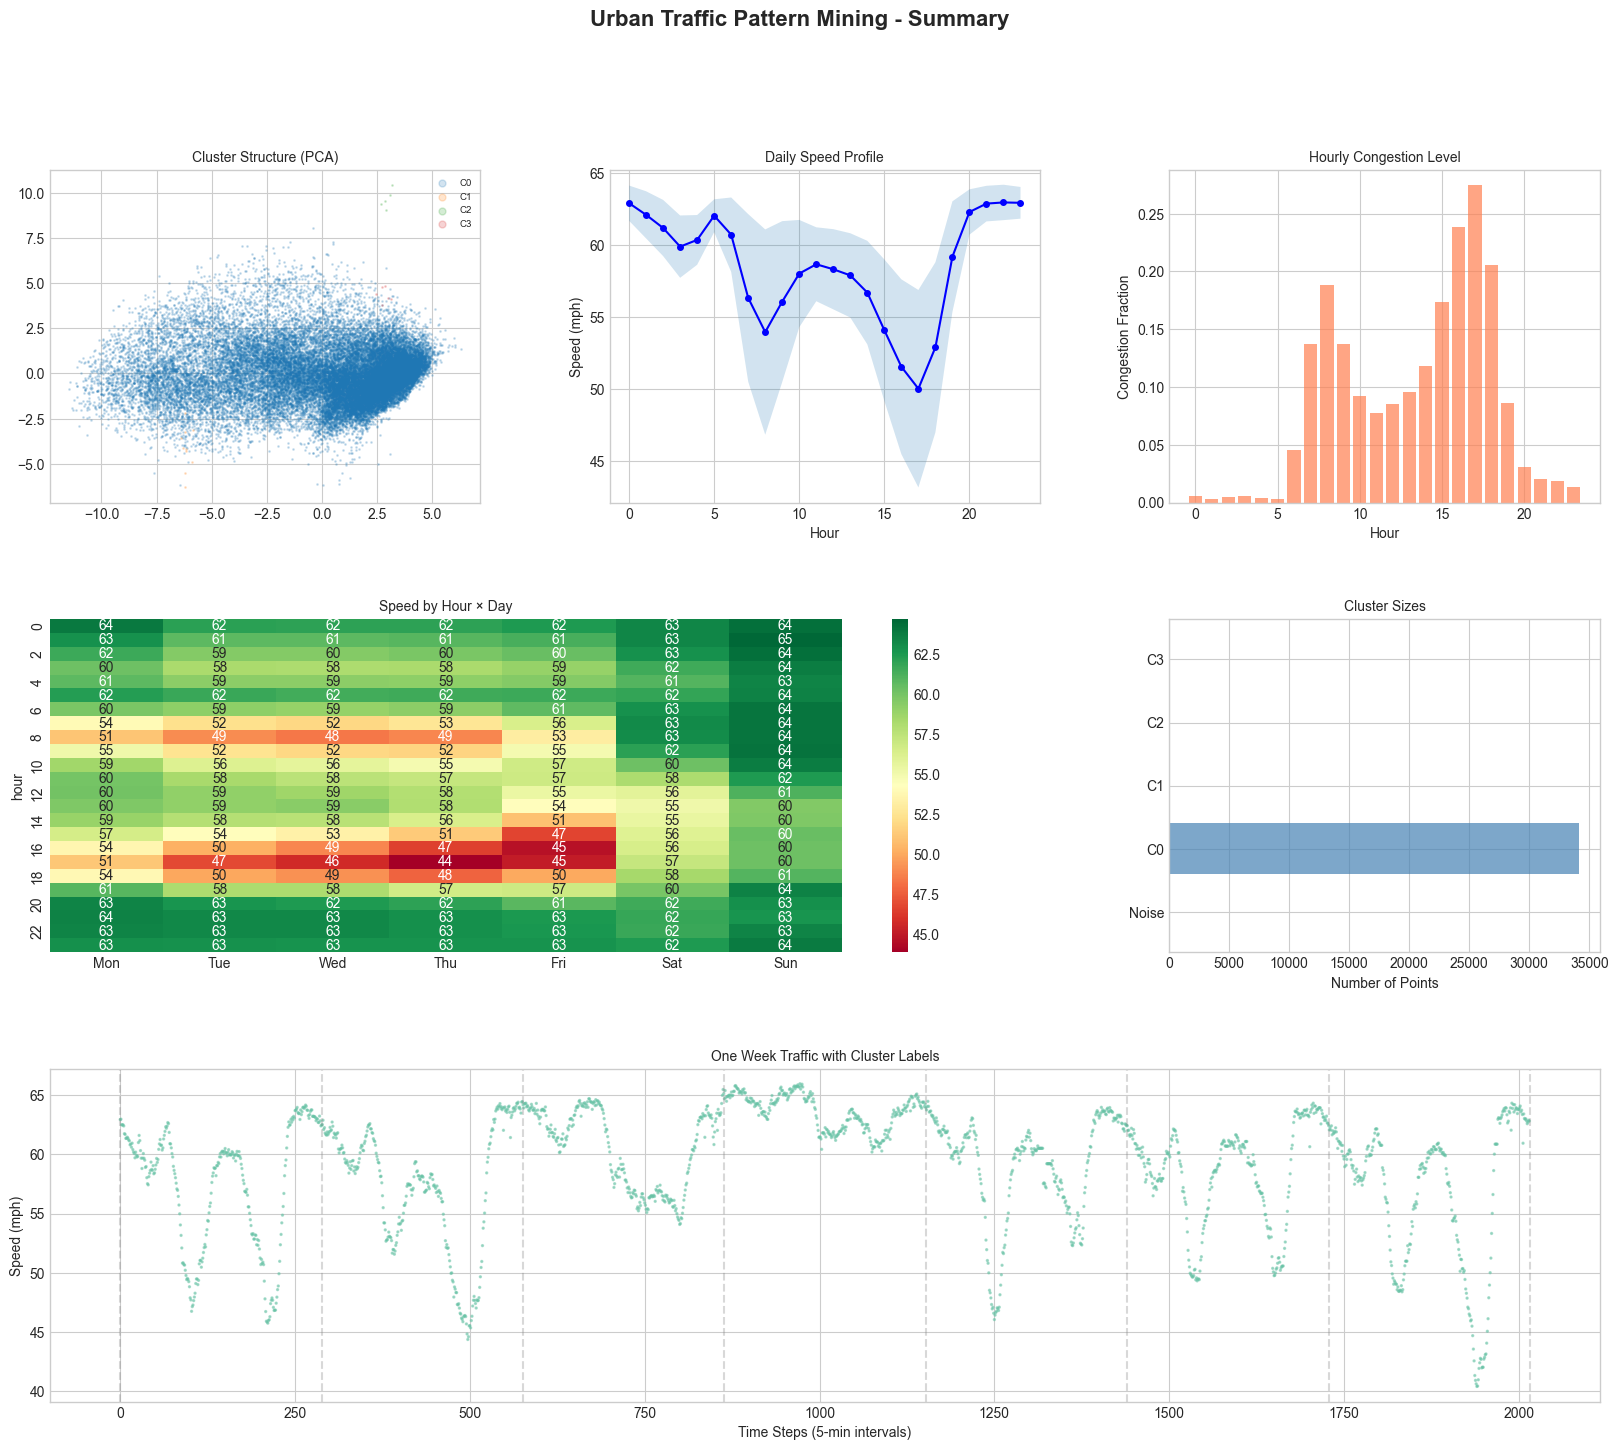


NOTEBOOK 4 COMPLETE


In [13]:


# ---- Cell 11: Comprehensive Summary Plot ----

fig = plt.figure(figsize=(20, 16))

gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
for label in sorted(set(final_labels)):
    if label == -1:
        continue
    mask = final_labels == label
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], s=1, alpha=0.2,
                label=f'C{label}')
ax1.set_title('Cluster Structure (PCA)', fontsize=10)
ax1.legend(markerscale=5, fontsize=7)

ax2 = fig.add_subplot(gs[0, 1])
hourly_speed = temporal_df.groupby('hour')['mean_speed'].agg(['mean', 'std'])
ax2.plot(hourly_speed['mean'], 'b-o', markersize=4)
ax2.fill_between(hourly_speed.index, hourly_speed['mean'] - hourly_speed['std'],
                 hourly_speed['mean'] + hourly_speed['std'], alpha=0.2)
ax2.set_title('Daily Speed Profile', fontsize=10)
ax2.set_xlabel('Hour')
ax2.set_ylabel('Speed (mph)')

ax3 = fig.add_subplot(gs[0, 2])
hourly_cong = temporal_df.groupby('hour')['frac_congested'].mean()
ax3.bar(hourly_cong.index, hourly_cong.values, color='coral', alpha=0.7)
ax3.set_title('Hourly Congestion Level', fontsize=10)
ax3.set_xlabel('Hour')
ax3.set_ylabel('Congestion Fraction')

ax4 = fig.add_subplot(gs[1, :2])
pivot = temporal_df.pivot_table(values='mean_speed', index='hour',
                                 columns='day_of_week', aggfunc='mean')
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.heatmap(pivot, cmap='RdYlGn', ax=ax4, annot=True, fmt='.0f')
ax4.set_title('Speed by Hour × Day', fontsize=10)

ax5 = fig.add_subplot(gs[1, 2])
cluster_sizes = pd.Series(final_labels).value_counts().sort_index()
labels_names = ['Noise' if k == -1 else f'C{k}' for k in cluster_sizes.index]
ax5.barh(labels_names, cluster_sizes.values, color='steelblue', alpha=0.7)
ax5.set_title('Cluster Sizes', fontsize=10)
ax5.set_xlabel('Number of Points')

ax6 = fig.add_subplot(gs[2, :])
week_data = temporal_df.iloc[:2016]
week_labels = final_labels[:2016]
scatter = ax6.scatter(range(len(week_data)), week_data['mean_speed'],
                      c=week_labels, cmap='Set2', s=2, alpha=0.5)
ax6.set_title('One Week Traffic with Cluster Labels', fontsize=10)
ax6.set_xlabel('Time Steps (5-min intervals)')
ax6.set_ylabel('Speed (mph)')
for day in range(8):
    ax6.axvline(x=day * 288, color='gray', linestyle='--', alpha=0.3)

fig.suptitle('Urban Traffic Pattern Mining - Summary', fontsize=16, fontweight='bold')
plt.savefig('../data/viz_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("NOTEBOOK 4 COMPLETE")
print("=" * 60)